Here we will test to see if the conditional vine cdf calculated through monte carlo methods produces the correct cdf!

This will be done using a conditional gaussian distribution. 

It can be calculated that if $X$ follows a multivariate normal distribution

$$\mathbf{X} \sim \mathbf{N}(\mu, \Sigma)$$

Then the conditional distribution of a subset of $X$, given it's complement, follows a multivariate normal distribution

$$\mathbf{X}_1|\mathbf{X}_2 \sim \mathbf{N}(\mu_{1|2}, \Sigma_{1|2})$$

where

$$
\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)\\

\Sigma_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}
$$


Initial code is a tweaked version of that from https://vinecopulib.github.io/pyvinecopulib/examples/03_vine_copulas_fit_sample.html, rbp sections are entirely our own.


In [2]:
import pyvinecopulib as pv
import numpy as np
import matplotlib.pyplot as plt
import rbp


from order_test import conditional_vine_copula
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.special import ndtr


In [3]:
np.random.seed(1234)  # seed for the random generator
n = 1000  # number of observations
d = 4  # the dimension
mean = 1 + np.random.normal(size=d)  # mean vector
cov = np.random.normal(size=(d, d))  # covariance matrix
cov = np.dot(cov.transpose(), cov)  # make it non-negative definite
print(cov)
print(cov[1:, 1:])
print(cov[0,1:])
print(cov[1:,0])
x = np.random.multivariate_normal(mean, cov, n)

test_point = np.random.multivariate_normal(mean, cov, 1)
given_cov = cov[0,0] + cov[0,1:]@np.linalg.inv(cov[1:, 1:])@cov[1:,0]
print(given_cov)
print(x.T[0].shape)

[[ 1.59271386 -2.48417931 -0.38417425 -0.15093703]
 [-2.48417931  9.98573908 -0.75938116 -3.24080217]
 [-0.38417425 -0.75938116  3.91854106 -1.45078951]
 [-0.15093703 -3.24080217 -1.45078951  3.78204036]]
[[ 9.98573908 -0.75938116 -3.24080217]
 [-0.75938116  3.91854106 -1.45078951]
 [-3.24080217 -1.45078951  3.78204036]]
[-2.48417931 -0.38417425 -0.15093703]
[-2.48417931 -0.38417425 -0.15093703]
3.0325768845525767
(1000,)


0.3050303310498439
0.7801424284598018
0.5042045649117808
0.4857637628800664


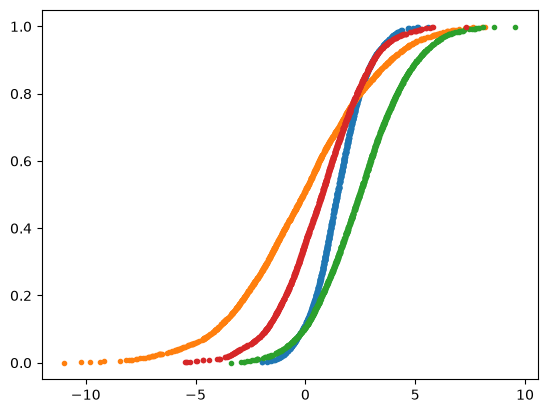

In [4]:
kdes = []
p0_grid = np.zeros((n,d))
P0_grid = np.zeros((n,d))

x_grid = np.linspace(-10, 15, num =1000)

test_pdf = np.zeros((1, d))
test_cdf = np.zeros((1, d))


for i in range(x.shape[1]):
    # Fit prior distributions and transform data for rbp
    kde = gaussian_kde(x.T[i])
    kdes.append(kde)
    p0_grid[:,i] = kde(x.T[i])
    P0_grid[:,i] = np.mean(ndtr((x.T[i] - kde.dataset.T) / kde.factor), axis=0)
    # Plot cdfs to check outputs
    plt.plot(x.T[i],P0_grid[:,i], '.')

    # Transform test data point
    test_pdf[:,i] = kde(test_point.T[i])
    test_cdf[:,i] = np.mean(ndtr((test_point.T[i] - kde.dataset.T) / np.sqrt(kde.covariance[0, 0])), axis=0)

    print(np.sqrt(kde.covariance[0, 0]))


Here we fit the RBP process, and gain the $\rho$s and fitted Us (the values used at each step of the RBP process).

We continue to calculate and plot the density of one marginal.

In [5]:
rhos, Us = rbp.fit_R_BP_marginals(p0_grid,P0_grid)
print(rhos, Us.shape)

[0.80947427 0.57802528 0.57417391 0.58859253] (1000, 4)


Transform the px and Px using the fitted values

[[0.55048942 0.31012612 0.39086733 0.73454083]]


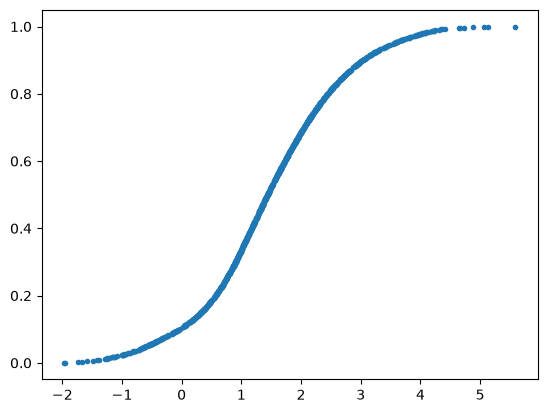

In [6]:

px, Px = rbp.R_BP_density_U(rhos, p0_grid, P0_grid, Us)

test_pdf, test_cdf = rbp.R_BP_density_U(rhos, test_pdf, test_cdf, Us)

#Check outputs
plt.plot(x.T[0], Px[:,0], '.')
print(test_cdf)

The initial fitting of a gaussian vine happens here

In [7]:
# Fit a Gaussian vine
# (i.e., properly specified since the data is multivariate normal)
controls = pv.FitControlsVinecop() #family_set=[pv.gaussian]
controls.conditioning_set = [2,3,4]
cop = pv.Vinecop.from_data(Px, controls=controls)
print(cop)
#cop.plot()

<pyvinecopulib.core.Vinecop> Vinecop model with 4 variables
tree edge conditioned variables conditioning variables var_types   family rotation parameters  df   tau 
   1    1                  1, 2                             c, c Gaussian        0      -0.61 1.0 -0.42 
   1    2                  2, 4                             c, c Gaussian        0      -0.53 1.0 -0.36 
   1    3                  3, 4                             c, c Gaussian        0      -0.42 1.0 -0.27 
   2    1                  1, 4                      2      c, c Gaussian        0      -0.56 1.0 -0.38 
   2    2                  2, 3                      4      c, c Gaussian        0      -0.40 1.0 -0.26 
   3    1                  1, 3                   4, 2      c, c Gaussian        0      -0.86 1.0 -0.66 



This should be the marginal distribution calculated by the RBP on a grid.

In [8]:
#Transform data using rbp marginal at index 0
#using x_grid above
allp_1 = kdes[0](x_grid)

P_1 = np.mean(ndtr((x_grid - kdes[0].dataset.T) / kdes[0].factor), axis=0)

u_1, U_1 = rbp.R_BP_density_U(rhos[0], allp_1, P_1, Us[:,0])

print(U_1.shape)

(1000,)


1.9589329290157916e-06


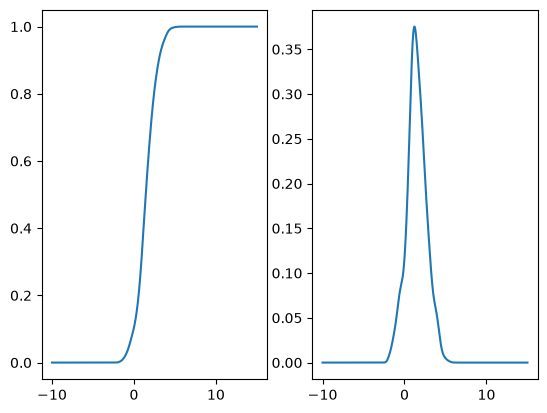

In [9]:
fig, ax = plt.subplots(1,2)
ax[0].plot(x_grid, U_1)
ax[1].plot(x_grid, u_1)
print(U_1[0])

Now we instantiate a conditional vine copula object using the copula we fitted earlier (with the conditional_set controls).

Then we take a transformed data point, repeat it to get the same conditioning values n times, and put the values transformed from a grid on [-10,10]->[0,1] as the conditioned variables. These are then passed through the conditional vine copula pdf and cdf_mc functions.

In [11]:
condcop = conditional_vine_copula(controls.conditioning_set, cop)
print(cop.order)
data = test_cdf
print("test_cdf shape:",data.shape)
print(data[0, 1:])
n_points = len(U_1)
value = 1
zero_to_data = np.linspace(0, value, n_points)
numer_inputs = np.repeat(data, n_points, axis=0)

numer_inputs[:, 0] = np.where(U_1<0.99999, np.where(U_1>1e-5, U_1,0), 1) 

given_mean = mean[0] + cov[0,1:]@np.linalg.inv(cov[1:, 1:])@(test_point[0, 1:]-mean[1:])
given_cov = cov[0,0] - cov[0,1:]@np.linalg.inv(cov[1:, 1:])@cov[1:,0]



true_cdf = norm.cdf(x_grid, loc = given_mean, scale = given_cov)


[1]
[1, 2, 3, 4]
test_cdf shape: (1, 4)
[0.31012612 0.39086733 0.73454083]


In [10]:
cdf_vals = condcop.cdf_mc(numer_inputs, n_samples = 10000)

[2 3 4]


In [11]:
def conditional_vine_copula_pdf(vine, u, u_condition, n_grid=300):

    eps = 1e-6
    u = np.clip(u, eps, 1 - eps)
    u_condition = np.asarray(u_condition)

    s_grid = np.linspace(eps, 1 - eps, n_grid)

    numerator_input = np.concatenate([[u], u_condition]).reshape(1, -1)
    numerator = vine.pdf(numerator_input)[0]

    denom_inputs = np.column_stack([s_grid, np.tile(u_condition, (n_grid, 1))])

    denom_values = vine.pdf(denom_inputs) 
    denominator = np.trapezoid(denom_values, s_grid) # integral

    cond_pdf = numerator / denominator
    #cond_pdf = max(cond_pdf, 1e-12)

    return cond_pdf

def conditional_vine_copula_cdf(vine, u, u_condition, n_grid=300):
    
    eps = 1e-6
    u = np.clip(u, eps, 1 - eps)
    u_condition = np.asarray(u_condition)

    # denominator
    s_full = np.linspace(eps, 1 - eps, n_grid)

    denom_inputs = np.column_stack([s_full, np.tile(u_condition, (n_grid, 1))])

    denom_values = vine.pdf(denom_inputs)
    denominator = np.trapezoid(denom_values, s_full)

    # numerator
    s_part = np.linspace(eps, u, n_grid)

    numer_inputs = np.column_stack([s_part, np.tile(u_condition, (n_grid, 1))])

    numer_values = vine.pdf(numer_inputs)
    numerator = np.trapezoid(numer_values, s_part)

    cond_cdf = numerator / denominator
    #cond_cdf = np.clip(cond_cdf, 0.0, 1.0)

    return cond_cdf

Here we plot the values against the true values to see if there is any difference.

We must make values of U_1 that are very close to 0 or 1 fall to those respective values as there can be a large number of values that do not go to 0 or 1 due to some form of numerical problem. This resulted in a line of values in the pdf not at 0, depending on what the actual value that didn't go to 0 or 1 was.

In [12]:

cdf = np.zeros_like(cdf_vals)
for i, val in enumerate(numer_inputs):

    cdf[i] = conditional_vine_copula_cdf(cop, val[0], val[1:])

3.028987861610743
1.6015420822693285 0.15285083733818072
[{'conditioned': (1, 2), 'conditioning': [], 'pair_copula': <pyvinecopulib.core.Bicop> Bivariate copula:
   family = Gaussian
   rotation = 0
   var_types = c,c
   parameters = -0.61
 }
 {'conditioned': (1, 4), 'conditioning': [2], 'pair_copula': <pyvinecopulib.core.Bicop> Bivariate copula:
   family = Gaussian
   rotation = 0
   var_types = c,c
   parameters = -0.56
 }
 {'conditioned': (1, 3), 'conditioning': [2, 4], 'pair_copula': <pyvinecopulib.core.Bicop> Bivariate copula:
   family = Gaussian
   rotation = 0
   var_types = c,c
   parameters = -0.86
 }                                                                                                           ]
--------
 [{'conditioned': (1, 2), 'conditioning': [], 'pair_copula': <pyvinecopulib.core.Bicop> Bivariate copula:
   family = Gaussian
   rotation = 0
   var_types = c,c
   parameters = -0.61
 }
 {'conditioned': (2, 4), 'conditioning': [], 'pair_copula': <pyvinecopulib.c

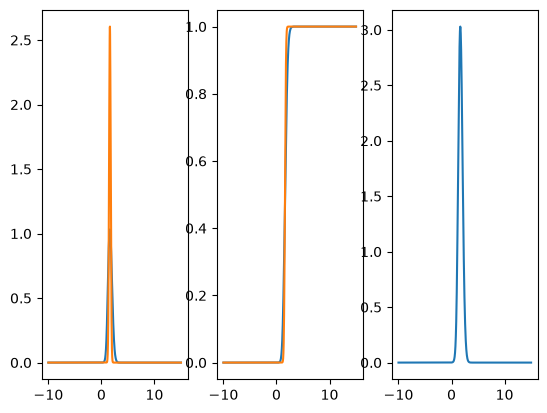

In [16]:
pdf_vals = condcop.pdf(numer_inputs)
pdf = np.zeros_like(pdf_vals)
cdf = np.zeros_like(cdf_vals)
for i, val in enumerate(numer_inputs):
    pdf[i] = conditional_vine_copula_pdf(cop, val[0], val[1:])
    cdf[i] = conditional_vine_copula_cdf(cop, val[0], val[1:])
print(max(pdf))

true_pdf = norm.pdf(x_grid, loc = given_mean, scale = given_cov)
print(given_mean, given_cov)

fig, ax = plt.subplots(1,3)
ax[0].plot(x_grid, pdf_vals*u_1)
ax[0].plot(x_grid, true_pdf)
# ax[0].plot(x_grid, pdf*u_1)

ax[1].plot(x_grid, cdf_vals, x_grid, true_cdf)
#ax[1].plot(x_grid, cdf)


ax[2].plot(x_grid, pdf_vals)
#print(min(x_grid[np.isclose(pdf_vals, 0.10747551)]))
print(condcop.subtrees_np)
print("--------\n", condcop.trees_np)

In [14]:
#Test without RBP marginals?
t = test_cdf.copy()
t[0, 0] = 0.000003
condcop.pdf(t)

# This says U_1 is getting a constant value here, it is not the fault of our calculations in the conditional copula sections!

array([2.00930257e-32])

It appears we centre almost perfectly on the mean of the conditional normal distribution, but have greater variance, which given we do not account for every connection with the simplified vine structure, is to be expected.

We do not attempt to simulate from this model as we only require evaluations of the cdf in order to fit a time varying copula, which we then must sample from!

Below here, we attempt to test the joint copula density to see whether it is calculating this correctly over the full distribution. There has beean a test of this before by using random numbers on $[0,1]^d$ to see whether our implementation outputted the same values as that of the pyvinecopulib implementation. This was succesful, but now we must check more thoroughly to see what the above problem is

I shall instantiate a conditional vine copula using the original vine, without passing a conditioning set. We shall then test it by MC simulation and, as we expect it to calculate the exact same value, we shall use np.allclose() to test whether they are the same evaluation.

If we do not see the same value, it may be pertinnent to use a KL divergence test. This is likely not required, as we do not expect the output to be an approximation, but rather the exact result.

A KL divergence may be more useful to quantify the conditional distributions, as this may change based on the exact specification of the vine - perhaps the order of conditioning variables? (It is unclear whether the order can change the fit in any way, or whether it simply performs the fitting process from scratch.)

In [15]:
n = 1000000
randpoints = np.random.uniform(size=(n, d))
print(randpoints.shape)
print(randpoints[0:5])

fullcop = conditional_vine_copula([], cop)

full_pds = fullcop.pdf(randpoints)
true_pds = cop.pdf(randpoints)

np.allclose(full_pds, true_pds, 1e-7)

(1000000, 4)
[[0.16499169 0.01112788 0.79317471 0.88098394]
 [0.83973095 0.21763516 0.42637705 0.66109514]
 [0.11874207 0.20369513 0.33536548 0.01880127]
 [0.1912268  0.6300294  0.01431059 0.66823572]
 [0.48776529 0.26317185 0.85326793 0.62378174]]
[1 2 3 4]


True

We get an output of True over 1 million random points with even greater tolerance requirements. We can fairly safely assume that the implementation of the full vine copula pdf calculation is correct.

That leaves us with whether the conditional copula pdf calculation is correct. For this, we must first check the maths as we are simply not including certain copulas within the calculations.